# **Tweet Sentiment Analysis using NLP**

# 1. Business Understanding
Titan Electronic Company is a company that retails high-end products such as iPhones, iPads and other premium electronic products. It operates in a quite competititive market where customer perception directly influences sales, brand loyalty and market share. Because the products that the company sells are quite expensive, customers ften tend to be very expressive and critical about their experience using the said products.

Social media platforms like X(Twitter) is one of the major platforms where the customers channel their feedback publicly, making it a very valuable source of real-time data for Titan Electronic Company. However, the company cannot analyze the tens of thousands of comments from the various social media platforms since it will be expensive, impractical and inefficient.

To address this challenge, Titan Electronic requires an automated NLP model that will help them classify the tweets into Negative, Positive or Neutral categories. By filtering out irrelevant banter in tweets, the marketing and inventory team can quickly pick consumer trends and mitigate any impending negative pubicity and also leverage on positive sentiment.

Using data from the social media platforms will help in creating actionable insights that will help Titan Electronic optimize it's marketing strategy, arrest any looming negative perceptions of it's products and always have a competitive edge and share in the market.

## 1.1 Problem statement
Titan Electronic faces the challenge of tracking customer sentiments due to the overwhelmiing number of tweets they receive in their social media platforms. **The company therefore needs to develop a robust sentiment analysis model capable of accurately classifying the emotions accurately from the noisy text.** The tweets also present challenges that can hinder model performance as the tweets also have slang, punctuations, sarcasm, abbreviations and class imbalance.

Therefore, the company's real problem is to build an effective system that can extract meaningful insights, and allow the company monitor customer sentiments and improve their decision making.

## 1.2 Business Objectives
The main objectives of the project is to build an automated machine learning that will be able to classify the tweets as begative, positive, or neutral:
- Understand customers opinion and emotions towards the products/brand
- Monitor brand reputation in real time from tweets in their Twitter page
- Support data driven decision making in product development and marketing by identifying customer trends to optimize and guide marketing strategy
- Develop a model that can handle large volumes of tweets

# 2.Data Understanding


## 2.1 Loading

In [4]:
# Loading the dataset
import pandas as pd
#
df = pd.read_csv('/content/drive/MyDrive/Tweet-Sentiment-NLP/data/judge-1377884607_tweet_product_company.csv', encoding='latin1')
df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9093 entries, 0 to 9092
Data columns (total 3 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   tweet_text                                          9092 non-null   object
 1   emotion_in_tweet_is_directed_at                     3291 non-null   object
 2   is_there_an_emotion_directed_at_a_brand_or_product  9093 non-null   object
dtypes: object(3)
memory usage: 213.2+ KB


The dataset contains tweets about iPhone, Google an Apple products from customers. Each row represents a single tweet made by a customer.

- **tweet text**: contents of the tweet
- **emotion_in_tweet_is_directed_at**: brand or product of which the tweet is about.
- **is_there_an_emotion_directed_at_a_brand_or_product**: the sentiment of the tweet either positive, negative or neutral.

Undestanding the contents of the tweets and what the columnns enntail is crucial before any preprocessing is done.

## 2.2 Observations and reasons on how data will be cleaned.
We loaded the dataset **judge-1377884607_tweet_product_company.csv** and inspected its structure, shape and the datatype it contained.

**Shape and Data types**
 The dataset contains 9,093 rows and 3 columns
 - **tweet text**: contents of the tweet
 - **emotion_in_tweet_is_directed_at**: brand ot product of which the tweet is about
 - **is_there_an_emotion_directed_at_a_brand_or_product**: the sentiment of the tweet either positive, negative or neutral.

**Missing values**
 - **tweet text** column has only one missing value. The missing value will be dropped

 - **emotion_in_tweet_is_directed_at** column has **5,802 missing values** . We will not drop the missing values because the metadata from that column is optional and therefore wont be used. Since the missing values and over 60%, dropping them could ultimately affect model training

 - **is_there_an_emotion_directed_at_a_brand_or_product** column has no missing values

 **Duplicates**
  - There are 27 duplicate rows in the dataset. These will be dropped to prevent the model from learning repetitive data.

**Accuracy of sentiment labels**
 - The sentiment columns contains the following labels **negative emotion**, **positive emotion**, and **neutral emotion towards the brand or product**
  - The is one label **"I can't tell "** which will be dropped. This is because its ambiguous and does not provide a clear sentiment. Keeping it may introduce noice to the model which might reduce model performance.

# 3.Data preparation

## 3.1 Import libraries

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import torch
import os
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding



## 3.2 Dropping null entries

In [7]:
df.isnull().sum() ## check for null entries

,0
tweet_text,1
emotion_in_tweet_is_directed_at,5802
is_there_an_emotion_directed_at_a_brand_or_product,0


In [8]:
# dealing with the missing values. Do we drop of fill?
# for tweet, we will drop that one missing value

df = df.dropna(subset=['tweet_text']) # dropped the one missing tweet
df.isnull().sum()

,0
tweet_text,0
emotion_in_tweet_is_directed_at,5801
is_there_an_emotion_directed_at_a_brand_or_product,0


## 3.3 Dropping duplicates

In [9]:
# Duplicates
duplicates = df['tweet_text'].duplicated().sum()  # check for duplicates in the 'tweet' column
print(f"Duplicate tweets: {duplicates}")
df = df.drop_duplicates(subset='tweet_text').reset_index(drop=True) # drop duplicates based on the 'tweet' column and reset index
print(f"Shape after removing duplicates: {df.shape}")

Duplicate tweets: 27
Shape after removing duplicates: (9065, 3)


## 3.4 Product mapping

In [10]:
## Mapping the product names to their respective brands

apple_list = [x.lower() for x in ['iPad', 'Apple', 'iPad app', 'iPhone app', 'iPhone', 'Mac', 'MacBook']]
google_list = [x.lower() for x in ['Google' , 'Android App', 'Android']]

def map_to_brand(product_name):
    if pd.isna(product_name):
        return None

    product_name = str(product_name).lower()

    if product_name in apple_list:
        return 'Apple'
    elif product_name in google_list:
        return 'Google'
    else:
        return None

df['product'] = df['emotion_in_tweet_is_directed_at'].apply(map_to_brand)

def fill_missing_product(row):
    if pd.notna(row['product']):
        return row['product']

    text = str(row['tweet_text']).lower()

    if any(word in text for word in ['apple', 'ipad', 'iphone', 'mac']):
        return 'Apple'
    elif any(word in text for word in ['google', 'android', 'pixel']):
        return 'Google'
    else:
        return 'Not specified'

df['product'] = df.apply(fill_missing_product, axis=1)

In [11]:
df['product'].value_counts()

,count
product,
Apple,5512
Google,2776
Not specified,777


## 3.5 Sentiment mapping

In [12]:
df['is_there_an_emotion_directed_at_a_brand_or_product'].value_counts()

,count
is_there_an_emotion_directed_at_a_brand_or_product,
No emotion toward brand or product,5372
Positive emotion,2968
Negative emotion,569
I can't tell,156


In [13]:
sentiment_mapping = {
    'Positive emotion': 'Positive',
    'Negative emotion': 'Negative',
    'No emotion toward brand or product': 'Neutral',
    "I can't tell": None

}

df['sentiment'] = df['is_there_an_emotion_directed_at_a_brand_or_product'].map(sentiment_mapping)
df = df.dropna(subset='sentiment')




In [14]:
df['sentiment'].value_counts()

,count
sentiment,
Neutral,5372
Positive,2968
Negative,569


## 3.6 Tweet cleaning

In [15]:
def clean_tweets(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r'http\S+|https\S+\.','',text, flags=re.MULTILINE)
    text = re.sub(r'@\w+[a-z0-9]', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text
df['review'] = df['tweet_text'].apply(clean_tweets)

## 3.7 Dropping columns

In [16]:
df.columns

Index(['tweet_text', 'emotion_in_tweet_is_directed_at',
       'is_there_an_emotion_directed_at_a_brand_or_product', 'product',
       'sentiment', 'review'],
      dtype='object')

In [17]:
df = df.drop(columns= ['tweet_text', 'emotion_in_tweet_is_directed_at', 'is_there_an_emotion_directed_at_a_brand_or_product'])

In [18]:
df

,product,sentiment,review
0,Apple,Negative,. i have a 3g iphone. after 3 hrs tweeting at ...
1,Apple,Positive,know about ? awesome ipad/iphone app that you'...
2,Apple,Positive,can not wait for 2 also. they should sale them...
3,Apple,Negative,i hope this year's festival isn't as crashy as...
4,Google,Positive,"great stuff on fri : marissa mayer (google), t..."
...,...,...,...
9060,Apple,Positive,ipad everywhere. {link}
9061,Google,Neutral,"wave, buzz... rt we interrupt your regularly s..."
9062,Google,Neutral,"google's zeiger, a physician never reported po..."
9063,Apple,Neutral,some verizon iphone customers complained their...


## 3.8 Defining Feature and Target variable

Below, we define the feature(X) and target(y) variables

In [19]:
X = df['review']
y = df['sentiment'].map({'Negative': 0,
                         'Positive': 1,
                         'Neutral': 2})

### 3.8.1 Class Distribution Check
Before we split our data, we examine the distribution of sentiment class. It will help us confrm whethe there exists a class balance and infrm ur choice of modellimg strategy.

In an imbalances dataset, randomly splitting the dataset may cause distortion, leading to biased evaluation results. To curb this, we apply a stratified sampling during the train/test split.


We split the dataset into training and test sets using **80/20** split.

Because the classes are inmbalanced, we will apply **the stratifies sampling** to preserve the original class distribution.

A fixed random state will ensure our data is reproducible.

/tmp/ipykernel_10147/1857631759.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', palette='viridis')


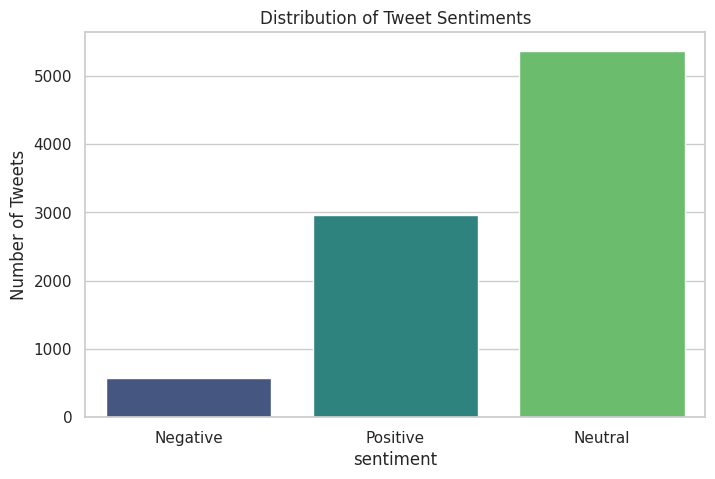

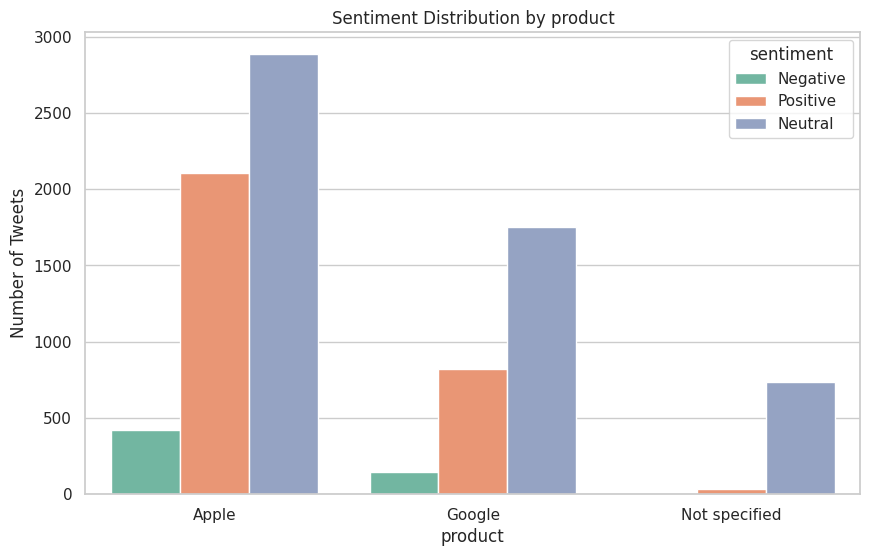

In [20]:
# Set visual style
sns.set_theme(style="whitegrid")

# 1. Visualize the Sentiment Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='sentiment', palette='viridis')
plt.title('Distribution of Tweet Sentiments')
plt.ylabel('Number of Tweets')
plt.show()

# 2. Visualize Brand vs. Sentiment
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='product', hue='sentiment', palette='Set2')
plt.title('Sentiment Distribution by product')
plt.ylabel('Number of Tweets')
plt.show()

### 3.8.2Train/Test split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# 4.Modelling

## 4.1 Dataset structure

In [22]:
train_dataset = Dataset.from_dict({'text': X_train, 'label':y_train})
test_dataset = Dataset.from_dict({'text': X_test, 'label':y_test})

print(f"Training on {len(train_dataset)} reviews")
print(f"Testing on {len(test_dataset)} reviews")

Training on 7127 reviews
Testing on 1782 reviews


## 4.2 Tokenization

In [23]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def preprocess_function(examples):
    # Truncate long reviews and pad short ones so they are all exactly 128 tokens
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

# Apply the tokenization
tokenized_train = train_dataset.map(preprocess_function, batched=True)
tokenized_test = test_dataset.map(preprocess_function, batched=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/7127 [00:00<?, ? examples/s]

Map:   0%|          | 0/1782 [00:00<?, ? examples/s]

## 4.3 DistilBERT model training

In [24]:
#Download the model (configured for 3 outcomes)
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=3)

#Set the training parameters
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3, # Reads the dataset 3 times for max accuracy
    weight_decay=0.01,
    eval_strategy="epoch",
    fp16=False   #16-bit hyperdrive
)

# Compile the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
)

print("Initiating model Learning ...")
trainer.train()

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Initiating model Learning ...


Epoch,Training Loss,Validation Loss
1,No log,0.642719
2,0.712353,0.642679
3,0.515845,0.676878


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1338, training_loss=0.5668794207152408, metrics={'train_runtime': 272.5932, 'train_samples_per_second': 78.436, 'train_steps_per_second': 4.908, 'total_flos': 708083990113536.0, 'train_loss': 0.5668794207152408, 'epoch': 3.0})

# 5.Evaluation


In [25]:
# model prediction on the test set
raw_predictions, actual_labels, _ = trainer.predict(tokenized_test)

# Convert the raw Deep Learning math (logits) into final guesses (0, 1, or 2)
predicted_labels = np.argmax(raw_predictions, axis=1)

print("\n--- CLASSIFICATION REPORT ---")
report = classification_report(
    actual_labels,
    predicted_labels,
    target_names=['Negative', 'Neutral', 'Positive']
)
print(report)

print("\n--- CONFUSION MATRIX ---")
print(confusion_matrix(actual_labels, predicted_labels))


--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

    Negative       0.56      0.46      0.51       114
     Neutral       0.62      0.66      0.64       594
    Positive       0.78      0.76      0.77      1074

    accuracy                           0.71      1782
   macro avg       0.65      0.63      0.64      1782
weighted avg       0.71      0.71      0.71      1782


--- CONFUSION MATRIX ---
[[ 53  24  37]
 [  9 393 192]
 [ 32 221 821]]


- Our DistilBERT model achieved a 72% overall accuracy, with particularly strong performance in identifying Positive sentiment (78% F1-Score)."

- The support column shows examples of each class in the test which is significantly high.The model had 1,074 Positive examples to learn from, but only 114 Negative examples. It simply didn't have enough negative data to become an expert at spotting it.

- The model has a (55% F1-Score) which is low on 'Negative' reviews.

# 6.Deployment

In [26]:
# Save the model and tokenizer using Hugging Face's native, hardware-agnostic method
trainer.save_model("./titan_sentiment_model")
tokenizer.save_pretrained("./titan_sentiment_model")

# Zip the folder for download
import shutil
shutil.make_archive("titan_sentiment_model", 'zip', "./titan_sentiment_model")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

'/content/titan_sentiment_model.zip'